# Libraries

In [1]:
from nptdms import TdmsFile
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import os

from scipy import signal
from scipy.signal import butter, lfilter, freqz, savgol_filter

import plotly
import plotly.offline as py
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import plotly.tools as tls
from ipywidgets import interactive, HBox, VBox, widgets, Output, interact, interact_manual, Layout, Box
py.init_notebook_mode(connected=True)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

import scaleogram as scg
import pywt


# VibrationData Class

In [2]:
class VibrationData():
    PLOT_TEMPLATE = 'plotly_white'

    def __init__(self, path, rpm, sampling_freq, n_flute=4, n_cycle=3, start_sec=3, fake=False, add_noise=False):
        self.path = path
        self.rpm = rpm
        self.n_cycle = n_cycle
        self.sampling_freq = sampling_freq
        self.n_flute = n_flute
        self.start_sec = start_sec
        self.add_noise=add_noise
        
        if fake:
                       
            
            # sec = 10
            # rpm = 120
            # n_flute = 4
            # expected_freq = int((rpm/60)*n_flute)
            # samplig_freq = 6000 # Hz
            # num_points_in_one_period = samplig_freq//expected_freq

            # skip_sin = 2 # number of skip sine wave

            # steps = np.linspace(0, sec, sec*samplig_freq)
            # orig = np.sin(2*np.pi*expected_freq*steps)
            # s = np.sin(2*np.pi*expected_freq*steps)
            # for i in range(0, len(steps), (skip_sin+1)*(num_points_in_one_period)):
            #     s[i:i+num_points_in_one_period*skip_sin]= 0.
            # s[s<0] = 0.

            skip_sin = 9 # number of skip sine wave

            steps = np.linspace(0, 10, 10*self.sampling_freq)
#             orig = np.sin(2*np.pi*self.expected_tooth_freq*steps)
            s = np.sin(2*np.pi*self.expected_tooth_freq*steps)
            for i in range(0, len(steps), (skip_sin+1)*(self.num_points_per_tooth)):
                s[i:i+self.num_points_per_tooth*(skip_sin)]= 0.
            s[s<0] = 0.
            
            self.reading = pd.DataFrame()
            self.reading['time'] = steps
            self.reading['data'] = s
            self.rpm = self.rpm //(skip_sin+1)
                           
            
            if self.add_noise:
                self.reading['data'] += np.random.randn(self.reading.shape[0])


        else:
            # read raw tdms data
            self.reading: pd.DataFrame = TdmsFile(path).as_dataframe()
            self.reading = self.reading.rename(
                columns={self.reading.columns[0]: "data"})
            
            # add time column
            self.reading['time'] = np.arange(self.__len__())*self.T
            
            # add ref signal: signal_freq*2 Hz
            self.reading['data'] += 0.01*np.sin(2*np.pi*self.expected_tooth_freq*2*self.reading['time'])

             # add ref signal: signal_freq*0.5 Hz
            self.reading['data'] += 0.005*np.sin(2*np.pi*self.expected_tooth_freq*0.5*self.reading['time'])

        # create aggregation columns
#         self.apply_aggregation()

    @property
    def T(self):
        return 1/self.sampling_freq
    
    @property
    def dt_tooth(self):
        return 1/((self.rpm/60)*self.n_flute)

    def apply_aggregation(self):

        # apply savgol filter
        SAVGOL_WINDOW_LEN = int(self.num_points_in_one_period/1)
        SAVGOL_WINDOW_LEN = SAVGOL_WINDOW_LEN if SAVGOL_WINDOW_LEN % 2 == 1 else SAVGOL_WINDOW_LEN+1
        self.reading['savgol'] = savgol_filter(self.reading['data'],
                                               window_length=SAVGOL_WINDOW_LEN,
                                               polyorder=1)
        # apply lowpass filter
        LOWPASS_ORDER = 2
        CUTOFF = 2500  # desired cutoff frequency of the filter, Hz
        self.reading['lowpass'] = self.butter_lowpass_filter(
            self.reading['data'], CUTOFF, self.sampling_freq, LOWPASS_ORDER)

        self.reading['lowpass+savgol'] = savgol_filter(self.reading['lowpass'],
                                                       window_length=SAVGOL_WINDOW_LEN,
                                                       polyorder=1)

    def __len__(self):
        return self.reading.shape[0]
    
    @property
    def expected_tooth_freq(self):
        return (self.n_flute*self.rpm/60)

    @staticmethod
    def _make_trace(data, colname, mode='lines'):
        return go.Scattergl(name=colname,
                            x=data['time'],
                            y=data[colname],
                            mode=mode,
                            marker=dict(line=dict(width=1)))

    def make_subset_after(self, sec):
        """make subset starting at 'sec' seconds"""
        self.start_sec = sec
        return self._make_subset(start_idx=int(self.sampling_freq*self.start_sec))

    def _make_subset(self, start_idx):
        return self.reading.iloc[start_idx:start_idx+self.num_points_in_one_period*self.n_cycle, :]

    def static_plot(self, save=True):
        plt.figure(figsize=(20, 10))
        plt.plot(self.reading['time'], self.reading['data'], '.')
        ax = plt.gca()
        if save:
            self.save_fig(ax.get_figure(), suffix='signal-full', kind='matplotlib')

    def plot(self, plot=True, save=True):
        def add_vline_per_period(fig):
                # add vertical line per period
                for i in range(self.n_cycle):
                    fig.add_shape(
                        # Line Vertical
                        dict(
                            type="line",
                            x0=subset['time'].iloc[self.num_points_in_one_period*i],
                            y0=subset['data'].max(),
                            x1=subset['time'].iloc[self.num_points_in_one_period*i],
                            y1=subset['data'].min(),
                            line=dict(
                                color="RoyalBlue",
                                width=3,
                                dash="dashdot"
                            )
                        ))
                return fig

        def init():

            # Create initial figure
            colnames = ['data', 'lowpass', 'savgol', 'lowpass+savgol']
            traces = [self._make_trace(
                data=subset, colname=colname, mode='lines') for colname in colnames]
            fig = go.FigureWidget(data=traces,
                                  layout=go.Layout(xaxis={'title': 'Time(sec)'},
                                                   yaxis={
                                      'title': 'Amplitude'},
                                      template=VibrationData.PLOT_TEMPLATE))
            fig = add_vline_per_period(fig)
            return fig

        # Create initial subset
        subset = self.make_subset_after(sec=self.start_sec)
        fig = init()

        # create min,max dictionary to faster update_range
        y_min_max_lookup = {
            d.name: {'min': d['y'].min(), 'max': d['y'].max()} for d in fig.data}

        def update_subset(start_sec):
            subset = self.make_subset_after(sec=start_sec)

            @interact(xaxis_range=widgets.FloatRangeSlider(min=subset['time'].iloc[0],
                                                           max=subset['time'].iloc[-1],
                                                           step=(
                                                               subset['time'].iloc[-1] - subset['time'].iloc[0]) / self.sampling_freq,
                                                           description='Time',
                                                           continuous_update=False,
                                                           readout=True,
                                                           readout_format='.3f',
                                                           layout=Layout(align_items='center',
                                                                         width='90%', height='80px')))
            def update_plot(xaxis_range):
                if len(fig.data) <= 3:
                    return

                # update traces with new subset
                for d in fig.data:
                    d['x'] = subset['time'].values
                    d['y'] = subset[d.name].values

                # update xaxis range wrt range slider
                fig.layout.xaxis.range = [xaxis_range[0], xaxis_range[1]]

                # update shapes wrt selected traces' max amplitude
                global_active_min_list = [
                    y_min_max_lookup[d.name]['min'] for d in fig.data if d.visible == True]
                global_active_max_list = [
                    y_min_max_lookup[d.name]['max'] for d in fig.data if d.visible == True]
                if len(global_active_min_list) and len(global_active_max_list):
                    _min = min(global_active_min_list)
                    _max = max(global_active_max_list)
                    for s in fig['layout']['shapes']:
                        s['y0'] = _max*1.1
                        s['y1'] = _min*1.1

#         def update_n_cycle(n_cycle):
#             self.n_cycle = n_cycle
#             subset = self.make_subset_after(sec=self.start_sec)
#             print(subset.shape)
#             fig['layout']['shapes'] = None
#             add_vline_per_period(fig)

#         n_cycle_slider_widget = interactive(update_n_cycle, n_cycle=widgets.IntSlider(value=self.n_cycle,
#                                                                               min=1,
#                                                                               max=100,
#                                                                               step=1,
#                                                                               description='Number of Cycle:',
#                                                                               disabled=False,
#                                                                               continuous_update=False,
#                                                                               readout=True,
#                                                                               readout_format='d'))

        control_widget = interactive(update_subset,
                                     start_sec=widgets.BoundedFloatText(value=subset['time'].iloc[0],  # means start_sec
                                                                        min=self.reading['time'].iloc[0],
                                                                        max=self.reading['time'].iloc[-1],
                                                                        step=0.5,
                                                                        description='Start Second:',
                                                                        disabled=False,
                                                                        layout=Layout(align_items='center',
                                                                                      width='50%',
                                                                                      )
                                                                        ))

        form = Box((control_widget, fig),
                   layout=Layout(display='flex',
                                 flex_flow='column',
                                 border='solid 2px',
                                 align_items='stretch',
                                 width='100%'))
        
        if save:
            self.save_fig(fig, suffix='signal', kind='plotly')
        if plot:
            display(form)
        
    
    def save_fig(self, fig, suffix, kind='plotly'):
        # path : 'D:/machining/wear_data/raw/1/acc7000.tdms'

        filename = self.path.stem # 'acc7000'
        foldername = self.path.parent.name # '1'

        images_path = self.path.parent.parent.parent/'images' # 'D:/machining/wear_data/images'
        specific_folder_path = images_path / foldername # 'D:/machining/wear_data/images/1'
        os.makedirs(specific_folder_path, exist_ok=True)

        save_path = specific_folder_path/filename # 'D:/machining/wear_data/images/1/acc7000.png
        
        if kind == 'plotly':
            # fig.write_image(str(save_path.with_suffix('.png')))
            fig.write_html(str(save_path.with_suffix(f'.{suffix}.html')))
        if kind == 'matplotlib':
            plt.savefig(str(save_path.with_suffix(f'.{suffix}.png')))
        
    def fft(self, data, bound=(0, 2500), plot=False, save=True):
        Fs = self.sampling_freq  # sampling freq
        Ts = 1/Fs  # sampling interval
        t = data['time']  # time vector

        n = data.shape[0]  # data lenght
        k = np.arange(n)
        T = n/Fs
        freq = k/T

        S = data['data'].values
        S_fft = np.fft.fft(S)

        freq = freq[:n//2]  # one side frequency range
        freq = freq[freq < bound[1]]  # cut unnecessary frequencies

        S_fft = S_fft.real[:freq.shape[0]] / \
            n  # fft computing and normalization
        S_fft = np.abs(S_fft)  # y-axis symetric correction

        fft_data = S_fft
        fft_freqs = freq

        
        
        fig = go.Figure(data=[go.Scattergl(x=fft_freqs, y=fft_data, name='fft', mode='markers+lines')],
                        layout=go.Layout(xaxis={'title': 'Freq(Hz)'},
                                         yaxis={'title': 'Amplitude'},
                                         template=VibrationData.PLOT_TEMPLATE))
        if save:
            self.save_fig(fig, suffix='fft', kind='plotly')
        if plot:
            fig.show()

    def spectrogram(self, data, bound=(0, 2500), plot=False, save=True, engine='plotly'):

        window = self.num_points_per_tooth*3
        nftt = self.num_points_per_tooth*100
#         noverlap=0
#         print(f"window:{window}  nftt:{nftt}")
        
        spect_freqs, spect_times, spectrogram_data = signal.spectrogram(
            x=data['data'],
            fs=self.sampling_freq,
            # increase in window : decrease in precision on time axis
            window=signal.windows.tukey(window, alpha=0.25, sym=False),
            # increase in nfft : increase in precision on freq axis
            nfft=nftt,
#             noverlap=0,
            scaling='spectrum',
            mode='magnitude')
        
        # cut unnecessary frequencies
        spect_freqs = spect_freqs[spect_freqs < bound[1]]
        spect_times = spect_times
        spectrogram_data = spectrogram_data[:spect_freqs.shape[0], :]

        
        fig = go.Figure(data=[go.Heatmap(z=spectrogram_data,
                                         x=spect_times,
                                         y=spect_freqs,
                                         name='spectrogram',
                                         hoverongaps=False,
                                         hovertemplate='X: %{x:.4f}h <br>Y: %{y} <br>Z: %{z}',)],
                        layout=go.Layout(xaxis={'title': 'Time(sec)'},
                                         yaxis={'title': 'Freq(Hz)'},
                                         template=VibrationData.PLOT_TEMPLATE),
                        )
            
        if engine=='matplotlib':

            fig, ax = plt.subplots(nrows=1)
            Pxx, freqs, bins, im = ax.specgram(data['data'], NFFT=self.num_points_per_tooth, 
                                               Fs=self.sampling_freq, noverlap=0)
            # The `specgram` method returns 4 objects. They are:
            # - Pxx: the periodogram
            # - freqs: the frequency vector
            # - bins: the centers of the time bins
            # - im: the matplotlib.image.AxesImage instance representing the data in the plot
            plt.show()
            
        if save:
            self.save_fig(fig, suffix='spectrogram', kind='plotly')
        if plot:
            fig.show()

    @property
    def num_points_in_one_period(self):
        """
        Return the number of data points for 1 revolution.
        """
        return int(self.sampling_freq/(self.rpm/60))
    
    @property
    def num_points_per_tooth(self):
        return self.num_points_in_one_period//self.n_flute

    @staticmethod
    def butter_lowpass_filter(data, cutoff, fs, order=5):
        # butter_lowpass
        nyq = 0.5 * fs
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        y = lfilter(b, a, data)
        return y

    def wavelet(self, data, wavelet='cmor6-1.5', xlim=None, ylim=None,clim=None, save=True):
        """
        X-axis: time
        Y-axis: scale - The scale correspond to the signal periodicity to which the transform is sentitive to.
        wavelets does not detect a single frequency but rather a band.
        fuzziness is proportional to the scale on y-axis
        wavelet_fun = <name><B>-<center-freq>
                    B: inversly proportional to bandwidth(smoothing) (The bandwidth parameter allow to tune the sensitivity on the period axis (Y). Or in other words the visibl amount of smoothing.)

        With logscale on Y axis, the bandwith will have the same height at all scales which may be helpful for data interpretation.
        ----------------------------------------------------------------------
        time   = np.arange(200, dtype=np.float16)-100
        data   =  np.exp(-0.5*((time)/0.2)**2)  # insert a gaussian at the center
        scales = np.arange(1,101) # scaleogram with 100 rows
        # compute ONCE the Continuous Wavelet Transform
        cwt    = scg.CWT(time, data, scales)

        # plot 1 with full range
        scg.cws(cwt)

        # plot 2 with a zoom
        scg.cws(cwt, xlim=(-50, 50), ylim=(20, 1))
    
        """


#         scales = np.arange(1, 500, 1)
        scales = scg.periods2scales(np.logspace(start=0, 
                                                stop=2.5,
                                                num=200) # 10**0 -- 10**2
                                   )

        cwt = scg.CWT(time = data['time'].values,
                   signal = data['data'].values-data['data'].mean(),
                   scales = scales,
                    wavelet=wavelet)

        ax=scg.cws(cwt,
                     spectrum = 'power',
                     figsize = (12, 6),
                     yscale = 'log',
                     ylabel = "Period [seconds]", 
                        xlabel = 'Time [seconds]',
                  xlim=xlim,ylim=ylim,clim=clim)
        
        text = ax.annotate("found freq", 
                           xy=(data['time'].iloc[100], 1/self.expected_tooth_freq), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05))        
        
        text = ax.annotate(f"Ref freq x2.0:{self.expected_tooth_freq*2}", 
                           xy=(data['time'].iloc[100], 1/(self.expected_tooth_freq*2)), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05))
        text = ax.annotate(f"Ref freq x0.5:{self.expected_tooth_freq*0.5}", 
                           xy=(data['time'].iloc[100], 1/(self.expected_tooth_freq*0.5)), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05)) 


        
#         ax.use_sticky_edges = False
#         p2f = lambda x:1/x
#         f2p = lambda x:1/x
#         secax = ax.secondary_yaxis('right', functions=(p2f, f2p))
#         secax.set_ylabel('Freq [Hz]')
#         pseudo_frequencies = pywt.scale2frequency(wavelet=wavelet, scale=scales)
#          for i in range(self.n_cycle):
#             ax.axvline(x=subset['time'].values[i*self.num_points_in_one_period], ymin=0.1, ymax=0.9, c='w')
        
#         # remove colorbar 
#         ax.collections[0].colorbar.remove()
        
        if save:
            self.save_fig(ax.get_figure(), suffix='wavelet', kind='matplotlib')
#         if plot:
#             fig.show()
     
        return (ax,cwt)

    def append_reading(self, other_reading):
        _other_reading=other_reading.copy()

        # update index
        interval=self.reading.index[1] - self.reading.index[0]
        elapsed_time=self.reading.index[-1] - \
            self.reading.index[0] + interval
        _other_reading.index += elapsed_time

        # update time column
        interval=self.reading.loc[:, 'time'].iloc[1] - \
            self.reading.loc[:, 'time'].iloc[0]
        elapsed_time=self.reading.loc[:, 'time'].iloc[-1] - \
            self.reading.loc[:, 'time'].iloc[0] + interval
        _other_reading['time'] += elapsed_time


    #         r_data = WearData(fpath=None)
    #         # update paths
    #         r_data.fpath = Path(os.path.commonpath([self.fpath, other.fpath]))
    #         r_data.outputpath = Path(os.path.commonpath([self.outputpath, other.outputpath]))
        # update tdms data
        self.reading=self.reading.append(_other_reading, verify_integrity=True)

        return self.reading

    def __str__(self):
        return f"""
                Path:{self.path}
                Shape:{self.reading.shape}
                RPM:{self.rpm}
                Sampling Frequency:{self.sampling_freq}
                Number of Cycle:{self.n_cycle}
                Number of Point in 1 Cycle:{self.num_points_in_one_period}
                T:{self.T}
                dt tooth: {self.dt_tooth*1000} ms
                expected_tooth_freq : {self.expected_tooth_freq} Hz
                -----------------------------------------
                Shape/Sampling Frequency =?: Elapsed Time -> {self.reading.shape[0]/self.sampling_freq} =? {self.reading['time'].iloc[-1]}
                
                
                """

# Real Data

In [3]:
NUM_CYCLE = 4
START_SEC = 3




# read data
kanal_no = 1
vib = VibrationData(path=Path(f'D:/machining/data/raw/17/accy_kanal{kanal_no}.tdms'),
                    rpm=7000,
                    sampling_freq=51200, n_flute=3, n_cycle=NUM_CYCLE)


# MEASUREMENT_TIMES = [
# #     7000, 
# #                      11340, 
#                      15120,
# #     18900, 22680,
# #                      30240, 37800, 41780, 45560, 49340, 53120, 56900
#         ]
# # MEASUREMENT_TIMES = [7800, 
# #                      15600, 23400, 31200, 39000
# #         ]
# vib = None
# for measurement_time in tqdm(MEASUREMENT_TIMES):
#     vib_current = VibrationData(path=Path(f'D:/machining/data/raw/1/acc{measurement_time}.tdms'),
#                                 rpm=3184,
#                                 sampling_freq=8000, 
#                                 n_flute=4, 
#                                 n_cycle=NUM_CYCLE)
    
# #     util(vib_current)
#     if vib is None:
#         vib = vib_current
#     else:
#         vib.append_reading(vib_current.reading)
        


# Data Plot

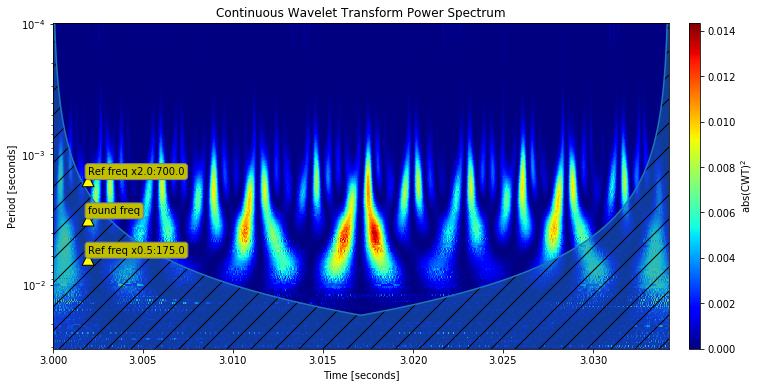

In [4]:
vib.apply_aggregation() # apply several filters
subset = vib.make_subset_after(sec=START_SEC)

# # # plot data
# vib.static_plot()
# vib.plot(plot=True)

# # plot fft
# vib.fft(data=subset,
#         plot=True)

# # plot spectrogram
# vib.spectrogram(data=subset,
#                 plot=True)

# plot wavelet
wavelet = 'cmor3-1.5'
wavelet = 'cgau5'
wavelet = 'cgau1'
wavelet = 'shan0.5-2'
wavelet = 'mexh'
wavelet = 'gaus2'
(ax,cwt) = vib.wavelet(data=subset, wavelet=wavelet)

In [ ]:
(ax, _) = vib.wavelet(data=subset, xlim=None, ylim=(0.8*10**-2, 2*10**-3), clim=(0.0028, 0.0030))

In [ ]:
ax.get_ylim()

In [116]:
print(vib)


                Path:D:\machining\data\raw\1\acc11340.tdms
                Shape:(3492000, 5)
                RPM:3184
                Sampling Frequency:8000
                Number of Cycle:5
                Number of Point in 1 Cycle:150
                T:0.000125
                dt tooth: 4.711055276381909 ms
                expected_tooth_freq : 212.26666666666668 Hz
                -----------------------------------------
                Shape/Sampling Frequency =?: Elapsed Time -> 436.5 =? 436.49987500000003
                
                
                


# Fake Data


                Path:
                Shape:(1000000, 5)
                RPM:5000
                Sampling Frequency:100000
                Number of Cycle:4
                Number of Point in 1 Cycle:1200
                T:1e-05
                dt tooth: 4.0 ms
                expected_tooth_freq : 250.0 Hz
                -----------------------------------------
                Shape/Sampling Frequency =?: Elapsed Time -> 10.0 =? 10.0
                
                
                


Box(children=(interactive(children=(BoundedFloatText(value=1.000001000001, description='Start Second:', layout…

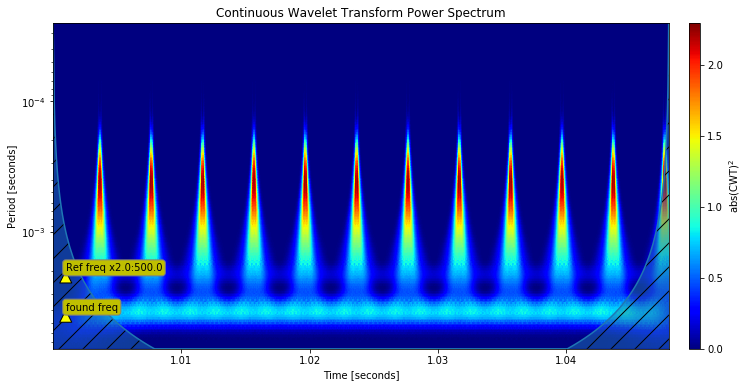

In [652]:
NUM_CYCLE =4
# read data
vib = VibrationData(path='',
                    rpm=5*10000, # create (rpm/60)*(n_flute) Hz vibration
                    sampling_freq=100000, n_cycle=NUM_CYCLE,
                    n_flute=3,
                       fake=True, add_noise=False)
vib.apply_aggregation() # apply several filters
subset = vib.make_subset_after(sec=1)
print(vib)
# vib.static_plot(save=False)
vib.plot(save=False)
# vib.fft(data=subset, plot=True, save=False)
# vib.spectrogram(data=subset, plot=True, save=False, engine='plotly')
ax, cwt = vib.wavelet(data=subset, wavelet='cgau5', save=False)


# Aux

In [ ]:
subset = vib.make_subset_after(sec=2.0)
colnames = ['data', 'lowpass', 'savgol', 'lowpass+savgol']
traces = [vib._make_trace(data=subset, colname=colname, mode='lines') for colname in colnames]
fig = go.FigureWidget(data=traces,
                      layout=go.Layout(xaxis={'title': 'Time(sec)'},
                                       yaxis={'title': 'Amplitude'},
                                       template=VibrationData.PLOT_TEMPLATE))

In [ ]:
fig.show()

In [ ]:
fig = vib.plot(subset)

In [ ]:
fig.data[0].name

In [ ]:
# load fig
fig = go.Figure("https://plot.ly/~jordanpeterson/889")

# find the range of the slider.
xmin, xmax = fig['layout']['xaxis']['range']

# create FigureWidget from fig
f = go.FigureWidget(data=fig.data, layout=fig.layout)

slider = widgets.FloatRangeSlider(
    min=xmin,
    max=xmax,
    step=(xmax - xmin) / 1000.0,
    readout=False,
    description='Time')
slider.layout.width = '800px'


# our function that will modify the xaxis range
def update_range(y):
    f.layout.xaxis.range = [y[0], y[1]]


# display the FigureWidget and slider with center justification
vb = VBox((f, interactive(update_range, y=slider)))
vb.layout.align_items = 'center'
vb

In [ ]:
import plotly.graph_objects as go

import pandas as pd

# Load data
df = pd.read_csv(
    "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv")
df.columns = [col.replace("AAPL.", "") for col in df.columns]

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=list(df.Date), y=list(df.High)))

# Set title
fig.update_layout(
    title_text="Time series with range slider and selectors"
)

# Add range slider
fig.update_layout(
    xaxis=dict(
#         rangeselector=dict(
#             buttons=list([
#                 dict(count=1,
#                      label="1m",
#                      step="month",
#                      stepmode="backward"),
#                 dict(count=6,
#                      label="6m",
#                      step="month",
#                      stepmode="backward"),
#                 dict(count=1,
#                      label="YTD",
#                      step="year",
#                      stepmode="todate"),
#                 dict(count=1,
#                      label="1y",
#                      step="year",
#                      stepmode="backward"),
#                 dict(step="all")
#             ])
#         ),
        rangeslider=dict(
            visible=True
        ),
        type="date"
    )
)

fig.show()

In [ ]:
x = widgets.IntText()
x

In [ ]:
x.value